# Dataset exploration

Initial notes and quick checks for the dataset.

# 1. Synthetic Dataset

In the previous notebook, `00_theoretical_foundations.ipynb`, we established the theory behind our NanoVLM:

- Image embeddings
- Text embeddings
- Shared embedding spaces
- Positive and negative image-text pairs
- Similarity matrices
- Contrastive learning
- Symmetric image-to-text and text-to-image loss

Now we will build the actual dataset that will be used by those components.

Instead of using a large real-world dataset, we will create a tiny **synthetic vision-language dataset** completely from scratch using Python and PIL.

The purpose is educational: we want complete control over the images, captions, and relationships between them.

Each sample will contain:

1. A `32 × 32` RGB image
2. A caption describing the image
3. Structured metadata describing the color, shape, and position

## Why Synthetic Data?

Real-world vision-language datasets contain many complications:

- Different image sizes
- Complex backgrounds
- Noisy captions
- Ambiguous descriptions
- Large amounts of data
- Difficult data collection

For our NanoVLM, these complications would make it harder to understand the actual multimodal learning process.

A synthetic dataset lets us isolate the important idea:

> **Can an image encoder and a text encoder learn that an image and its corresponding caption represent the same concept?**

The dataset is intentionally simple so that we can inspect individual examples and understand exactly why a particular image corresponds to a particular caption.

## Dataset Design

Our dataset is constructed from three independent attributes:

- **9 colors**
- **3 shapes**
- **9 spatial positions**

Therefore, the total number of unique combinations is:

$$
N =
N_{\text{colors}}
\times
N_{\text{shapes}}
\times
N_{\text{positions}}
$$

So:

$$
N = 9 \times 3 \times 9 = 243
$$

This gives us exactly **243 unique image-caption pairs**.

For example:

```text
red + circle + top-left

produces the caption:

"red circle top-left"

In [1]:



# Core imports

import random
import itertools

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
from torch.utils.data import Dataset, DataLoader

## Reproducibility

We will use fixed random seeds throughout the notebook.

This makes our dataset generation and train/validation split deterministic.

Reproducibility is important because we want to obtain the same experiment every time the notebook is executed.

In [2]:
# Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


# 2. Define Dataset Attributes

Our synthetic images are generated from three attributes:

1. Color
2. Shape
3. Position

Every combination of these attributes corresponds to exactly one image-caption pair.

In [3]:
# Dataset attributes

COLORS = {
    "red": (255, 0, 0),
    "green": (0, 180, 0),
    "blue": (0, 100, 255),
    "yellow": (255, 220, 0),
    "purple": (150, 70, 200),
    "orange": (255, 140, 0),
    "pink": (255, 105, 180),
    "brown": (150, 90, 40),
    "gray": (128, 128, 128),
}

SHAPES = [
    "square",
    "circle",
    "triangle",
]

POSITIONS = [
    "top-left",
    "top-center",
    "top-right",
    "middle-left",
    "center",
    "middle-right",
    "bottom-left",
    "bottom-center",
    "bottom-right",
]

print("Number of colors:", len(COLORS))
print("Number of shapes:", len(SHAPES))
print("Number of positions:", len(POSITIONS))

Number of colors: 9
Number of shapes: 3
Number of positions: 9


## Dataset Size

We can verify the expected number of samples directly:

$$
9 \times 3 \times 9 = 243
$$

Each sample will have a unique combination of:

```text
color + shape + position

In [5]:




# Verify expected dataset size

NUM_COLORS = len(COLORS)
NUM_SHAPES = len(SHAPES)
NUM_POSITIONS = len(POSITIONS)

EXPECTED_SAMPLES = NUM_COLORS * NUM_SHAPES * NUM_POSITIONS

print(f"Expected number of samples: {EXPECTED_SAMPLES}")

assert EXPECTED_SAMPLES == 243

Expected number of samples: 243


# 3. Generate All Combinations

The simplest way to construct all possible combinations is to use a **Cartesian product**.

For example:

```text
colors × shapes × positions

In [7]:




# Generate every possible combination

combinations = list(
    itertools.product(
        COLORS.keys(),
        SHAPES,
        POSITIONS,
    )
)

print("Number of combinations:", len(combinations))

assert len(combinations) == 243

Number of combinations: 243


## Creating Captions

Each combination can be converted into a deterministic caption.

For example:

```text
color  = red
shape  = circle
position = top-left

becomes:

"red circle top-left"

In [9]:


def make_caption(color, shape, position):
    """
    Convert structured metadata into a deterministic caption.
    """
    return f"{color} {shape} {position}"


# Example
example_caption = make_caption("red", "circle", "top-left")

print(example_caption)

red circle top-left


# 4. Image Generation

Each image will be:

- `32 × 32`
- RGB
- Simple and consistent
- Containing exactly one geometric object

The object will be placed according to its position label.

For example:

```text
"red circle top-left"

In [11]:




# Image configuration

IMAGE_SIZE = 32

# Simple white background
BACKGROUND_COLOR = (255, 255, 255)

# Object size
OBJECT_SIZE = 10

## Mapping Positions to Coordinates

We use a `3 × 3` spatial grid:

```text
top-left       top-center       top-right

middle-left    center           middle-right

bottom-left    bottom-center    bottom-right

In [13]:

# Map each position label to an (x, y) coordinate

POSITION_COORDINATES = {
    "top-left": (8, 8),
    "top-center": (16, 8),
    "top-right": (24, 8),

    "middle-left": (8, 16),
    "center": (16, 16),
    "middle-right": (24, 16),

    "bottom-left": (8, 24),
    "bottom-center": (16, 24),
    "bottom-right": (24, 24),
}

In [14]:
def draw_sample(color, shape, position, image_size=IMAGE_SIZE):
    """
    Create a synthetic 32x32 RGB image containing one
    colored geometric object at the requested position.
    """

    image = Image.new(
        "RGB",
        (image_size, image_size),
        BACKGROUND_COLOR
    )

    draw = ImageDraw.Draw(image)

    center_x, center_y = POSITION_COORDINATES[position]

    half_size = OBJECT_SIZE // 2

    left = center_x - half_size
    top = center_y - half_size
    right = center_x + half_size
    bottom = center_y + half_size

    rgb_color = COLORS[color]

    if shape == "square":
        draw.rectangle(
            [left, top, right, bottom],
            fill=rgb_color
        )

    elif shape == "circle":
        draw.ellipse(
            [left, top, right, bottom],
            fill=rgb_color
        )

    elif shape == "triangle":
        draw.polygon(
            [
                (center_x, top),
                (left, bottom),
                (right, bottom),
            ],
            fill=rgb_color
        )

    else:
        raise ValueError(f"Unknown shape: {shape}")

    return image

## Test the Image Generator

Before generating the complete dataset, we should verify that the image-generation function works correctly.

We will create one example:

```text
red circle top-left

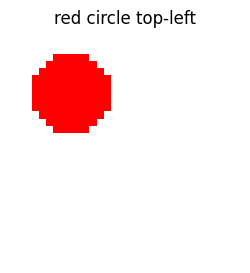

In [15]:




# Test one generated image

test_image = draw_sample(
    color="red",
    shape="circle",
    position="top-left",
)

plt.figure(figsize=(3, 3))
plt.imshow(test_image)
plt.title("red circle top-left")
plt.axis("off")
plt.show()

# 5. Generate the Full Dataset

Now we combine:

- All colors
- All shapes
- All positions
- Caption generation
- Image generation

Each sample will be stored as a dictionary containing:

```text
image
caption
color
shape
position

In [16]:




# Generate all 243 samples

samples = []

for color, shape, position in combinations:
    image = draw_sample(
        color=color,
        shape=shape,
        position=position,
    )

    caption = make_caption(
        color=color,
        shape=shape,
        position=position,
    )

    samples.append({
        "image": image,
        "caption": caption,
        "color": color,
        "shape": shape,
        "position": position,
    })

print("Total samples:", len(samples))

assert len(samples) == 243

Total samples: 243


# 6. Inspect the Dataset

A dataset should always be inspected visually before training.

We want to verify that:

- The colors are correct
- The shapes are correct
- The positions are correct
- The captions match the images

We will display several randomly selected examples.

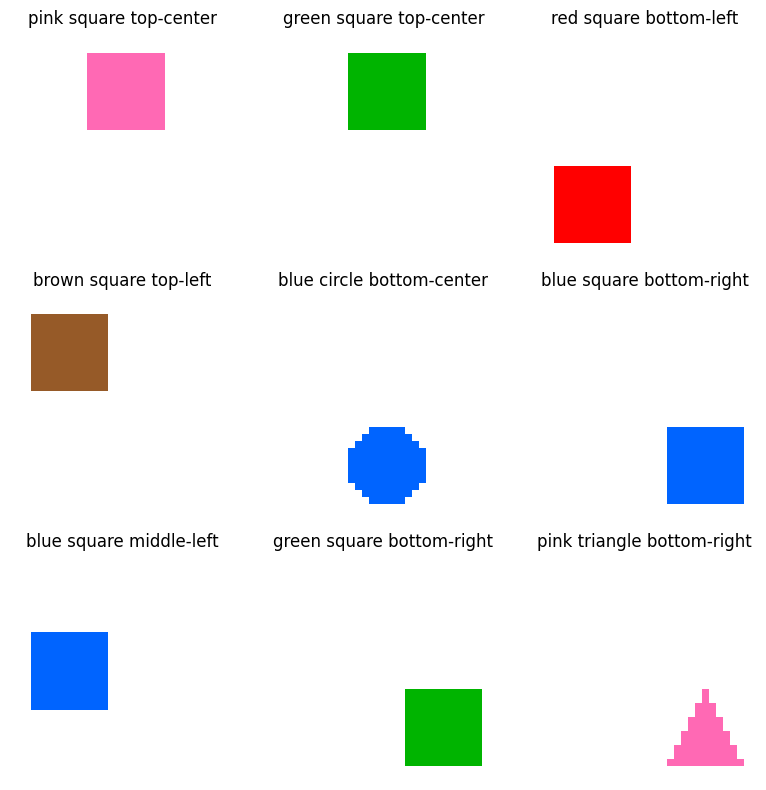

In [17]:
# Display random dataset samples

rng = random.Random(SEED)

sample_indices = rng.sample(
    range(len(samples)),
    9
)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, index in zip(axes.flat, sample_indices):
    sample = samples[index]

    ax.imshow(sample["image"])
    ax.set_title(sample["caption"])
    ax.axis("off")

plt.tight_layout()
plt.show()

# 7. Verify Dataset Coverage

The dataset should contain exactly:

- 9 unique colors
- 3 unique shapes
- 9 unique positions
- 243 unique combinations

We will verify these properties programmatically.

Assertions are useful here because they immediately tell us if the dataset construction has an error.

In [18]:
# Extract attributes

unique_colors = set(sample["color"] for sample in samples)
unique_shapes = set(sample["shape"] for sample in samples)
unique_positions = set(sample["position"] for sample in samples)

unique_combinations = set(
    (
        sample["color"],
        sample["shape"],
        sample["position"],
    )
    for sample in samples
)

print("Unique colors:", len(unique_colors))
print("Unique shapes:", len(unique_shapes))
print("Unique positions:", len(unique_positions))
print("Unique combinations:", len(unique_combinations))

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243


In [19]:
# Dataset verification

assert len(samples) == 243
assert len(unique_colors) == 9
assert len(unique_shapes) == 3
assert len(unique_positions) == 9
assert len(unique_combinations) == 243

print("✓ Dataset coverage verified.")

✓ Dataset coverage verified.


# 8. Positive and Negative Image-Text Pairs

The dataset naturally creates positive image-text pairs.

For example:

```text
Image:
red circle at the top-left

Caption:
"red circle top-left"


### Markdown Cell 30

```markdown
# 9. Train / Validation Split

We will split the 243 samples into:


80 % training


and:


20%  validation


The split will be deterministic using our fixed random seed.

This is important because:

1. We want reproducible experiments.
2. Validation samples must not be used for training.
3. We need unseen examples to evaluate whether the model learned the underlying relationships.

In [20]:
# Deterministic train/validation split

indices = list(range(len(samples)))

split_rng = random.Random(SEED)
split_rng.shuffle(indices)

split_index = int(0.8 * len(indices))

train_indices = indices[:split_index]
val_indices = indices[split_index:]

train_samples = [samples[i] for i in train_indices]
val_samples = [samples[i] for i in val_indices]

print("Total samples:", len(samples))
print("Training samples:", len(train_samples))
print("Validation samples:", len(val_samples))

assert len(train_samples) + len(val_samples) == len(samples)

Total samples: 243
Training samples: 194
Validation samples: 49


## Split Summary

Because the dataset contains 243 samples, an 80/20 split gives approximately:

- **194 training samples**
- **49 validation samples**

The exact numbers come from taking 80% of 243 and assigning the remaining samples to validation.

In [21]:
print(f"Train: {len(train_samples)} samples")
print(f"Validation: {len(val_samples)} samples")

Train: 194 samples
Validation: 49 samples


# 10. PyTorch Dataset

Now we convert our generated data into a PyTorch `Dataset`.

The Dataset will:

1. Store the image-caption pairs.
2. Convert PIL images into PyTorch tensors.
3. Convert images from:

$$
H \times W \times C
$$

to:

$$
C \times H \times W
$$

because PyTorch convolutional models expect image tensors in **CHW** format.

Pixel values will be converted to the range:

$$
[0,1]
$$

We will not apply ImageNet normalization because our image encoder is being built completely from scratch and is not pretrained on ImageNet.

In [22]:
class SyntheticVLDataset(Dataset):
    """
    PyTorch Dataset for the synthetic NanoVLM data.
    """

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]

        # PIL image -> NumPy array
        image = np.array(sample["image"], dtype=np.float32)

        # [H, W, C] -> [C, H, W]
        image = torch.from_numpy(image).permute(2, 0, 1)

        # Normalize pixel values from [0, 255] -> [0, 1]
        image = image / 255.0

        return {
            "image": image,
            "caption": sample["caption"],
            "color": sample["color"],
            "shape": sample["shape"],
            "position": sample["position"],
        }

# 11. Create Train and Validation Datasets

We can now create separate PyTorch datasets for training and validation.

In [23]:
train_dataset = SyntheticVLDataset(train_samples)
val_dataset = SyntheticVLDataset(val_samples)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 194
Validation dataset: 49


In [24]:
# Inspect one dataset item

sample = train_dataset[0]

print("Image shape:", sample["image"].shape)
print("Caption:", sample["caption"])
print("Color:", sample["color"])
print("Shape:", sample["shape"])
print("Position:", sample["position"])

Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left


The image should now have the shape:

$$
[3, 32, 32]
$$

This is the format expected by a PyTorch convolutional image encoder.

The caption remains a Python string for now.

We will build the tokenizer and text encoder in a later notebook.

# 12. Text Representation

For this notebook, we will **not** build the complete text encoder.

Instead, we keep captions as strings.

The later text-processing pipeline will look conceptually like:

```text
Dataset
   ↓
Caption string
   ↓
Tokenizer
   ↓
Token IDs
   ↓
Text Encoder
   ↓
Text Embedding




# 13. DataLoaders

The next step is to create PyTorch `DataLoader`s.

A DataLoader groups individual samples into batches.

For example, with: batch_size=32


In [26]:



# DataLoader configuration

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 7
Validation batches: 2


# 14. Inspect a Batch

Let's inspect the first training batch.

This is important because later notebooks will depend on exactly this data format.

In [27]:
# Inspect one batch

batch = next(iter(train_loader))

print("Image batch shape:", batch["image"].shape)
print("Number of captions:", len(batch["caption"]))

print("\nFirst five captions:")
for caption in batch["caption"][:5]:
    print("-", caption)

Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


The batch will eventually flow through the NanoVLM like this:

```text
Images
   ↓
Image Encoder
   ↓
Image Embeddings

and

Captions
   ↓
Tokenizer
   ↓
Text Encoder
   ↓
Text Embeddings


then:

Image Embeddings × Text Embeddings
              ↓
       Similarity Matrix
              ↓
       Contrastive Loss





# 15. Visualize a Training Batch

Let's visualize a complete batch subset again, this time directly from the PyTorch DataLoader.

This confirms that the DataLoader preserves the image-caption relationship.

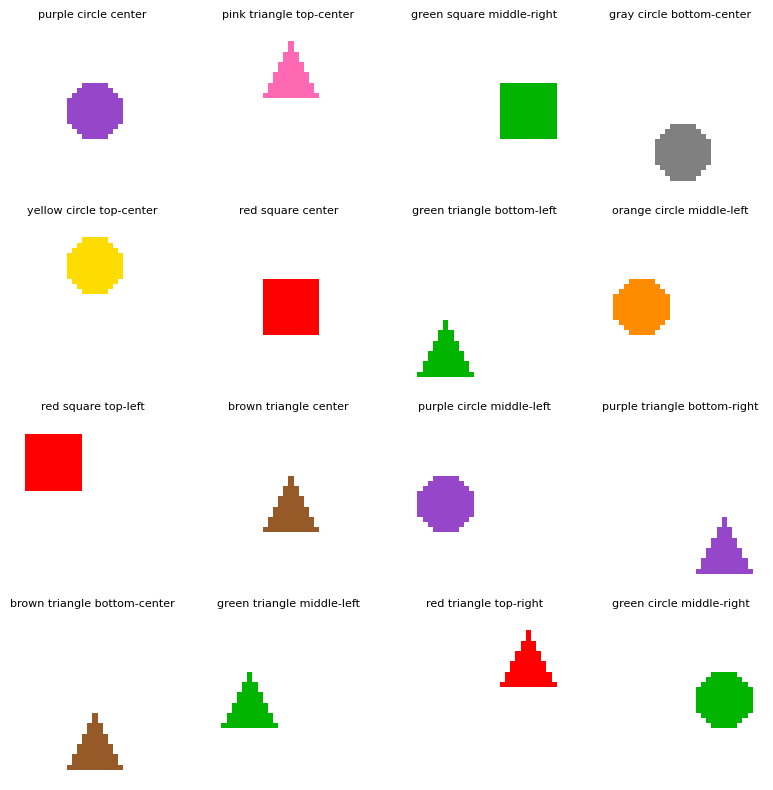

In [28]:
# Visualize images from one training batch

batch = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    image = batch["image"][i]

    # CHW -> HWC
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(batch["caption"][i], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 16. Final Dataset Summary

Our synthetic NanoVLM dataset contains:

| Property | Value |
|---|---:|
| Total samples | 243 |
| Training samples | 194 |
| Validation samples | 49 |
| Image size | $32 \times 32$ |
| Channels | 3 |
| Colors | 9 |
| Shapes | 3 |
| Positions | 9 |

The complete dataset is generated from:

$$
9 \times 3 \times 9 = 243
$$

unique combinations.

Each image has exactly one corresponding caption.

The dataset is intentionally tiny and structured.

Its purpose is **not** to create a useful real-world VLM. Instead, it provides a controlled environment in which we can understand how image and text encoders learn a shared embedding space through contrastive learning.

# 17. Connection to the Next Stages

The dataset is now ready for the next components of the NanoVLM.

The overall pipeline is:

```text
01_dataset.ipynb
        ↓
02_image_encoder.ipynb
        ↓
03_text_encoder.ipynb
        ↓
04_contrastive_loss.ipynb
        ↓
05_training.ipynb
        ↓
06_retrieval_and_evaluation.ipynb

In [29]:



# Final sanity check

print("=" * 50)
print("NanoVLM Synthetic Dataset")
print("=" * 50)

print(f"Total samples       : {len(samples)}")
print(f"Training samples    : {len(train_dataset)}")
print(f"Validation samples  : {len(val_dataset)}")
print(f"Image size          : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Colors              : {len(COLORS)}")
print(f"Shapes              : {len(SHAPES)}")
print(f"Positions           : {len(POSITIONS)}")
print(f"Expected combinations: {EXPECTED_SAMPLES}")

assert len(samples) == 243
assert len(train_dataset) == 194
assert len(val_dataset) == 49
assert batch["image"].shape[1:] == (3, 32, 32)

print("\n✓ Dataset notebook completed successfully.")

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.


In [30]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [31]:
!git init


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [32]:
!git add .

In [35]:
!git commit -m 'dataset created'

[master (root-commit) 587cba2] dataset created
 21 files changed, 51059 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.06.04/13.31.42.499627.log
 create mode 100644 .config/logs/2026.06.04/13.32.02.654775.log
 create mode 100644 .config/logs/2026.06.04/13.32.18.735754.log
 create mode 100644 .config/logs/2026.06.04/13.32.21.210570.log
 create mode 100644 .config/logs/2026.06.04/13.32.38.346437.log
 create mode 100644 .config/logs/2026.06.04/13.32.39.344962.log
 create mode 100755 sample_data/README.md
 create mode 100

In [34]:
!git config --global user.email "asimshahicp@gmail.com"
!git config --global user.name "Asim Shah"

In [36]:
%cd /content/drive/MyDrive/Build-A-NanoVLM-From-Scratch


[Errno 2] No such file or directory: '/content/drive/MyDrive/Build-A-NanoVLM-From-Scratch'
/content
